In [47]:
import pandas as pd
import numpy as np
import seaborn as sns

In [48]:
data = {
    "Customer_ID": [101,102,103,104,105,106,107,108,109,110],
    "Age": [25,32,28,np.nan,45,36,29,150,41,33],
    "Gender": ["Male","Female","Female","Male","Male",
               "Female","female","Male","Female","Male"],
    "City": ["Kochi","Calicut","Kochi","Palakkad",np.nan,
             "Kochi","Calicut","Palakkad","Kochi","Calicut"],
    "Income": [30000,45000,38000,52000,80000,np.nan,
               42000,500000,67000,48000],
    "Purchase_Amount": [5000,7000,6000,8000,15000,9000,
                        6500,20000,12000,7500],
    "Membership": ["Basic","Premium","Basic","Premium",
                   "Gold","Basic","Premium","Gold","Gold","Basic"],
    "Purchased": [0,1,0,1,1,0,1,1,1,0]
}
df=pd.DataFrame(data)

In [49]:
df.isnull().sum()

Customer_ID        0
Age                1
Gender             0
City               1
Income             1
Purchase_Amount    0
Membership         0
Purchased          0
dtype: int64

In [50]:
df["Age"] = df['Age'].fillna(df['Age'].median()).astype(int)
df['Income']=df['Income'].fillna(df['Income'].median())
df['City']=df['City'].fillna('Unknown')
df

,Customer_ID,Age,Gender,City,Income,Purchase_Amount,Membership,Purchased
0,101,25,Male,Kochi,30000.0,5000,Basic,0
1,102,32,Female,Calicut,45000.0,7000,Premium,1
2,103,28,Female,Kochi,38000.0,6000,Basic,0
3,104,33,Male,Palakkad,52000.0,8000,Premium,1
4,105,45,Male,Unknown,80000.0,15000,Gold,1
5,106,36,Female,Kochi,48000.0,9000,Basic,0
6,107,29,female,Calicut,42000.0,6500,Premium,1
7,108,150,Male,Palakkad,500000.0,20000,Gold,1
8,109,41,Female,Kochi,67000.0,12000,Gold,1
9,110,33,Male,Calicut,48000.0,7500,Basic,0


In [51]:
df['Gender']=df['Gender'].str.lower()
df

,Customer_ID,Age,Gender,City,Income,Purchase_Amount,Membership,Purchased
0,101,25,male,Kochi,30000.0,5000,Basic,0
1,102,32,female,Calicut,45000.0,7000,Premium,1
2,103,28,female,Kochi,38000.0,6000,Basic,0
3,104,33,male,Palakkad,52000.0,8000,Premium,1
4,105,45,male,Unknown,80000.0,15000,Gold,1
5,106,36,female,Kochi,48000.0,9000,Basic,0
6,107,29,female,Calicut,42000.0,6500,Premium,1
7,108,150,male,Palakkad,500000.0,20000,Gold,1
8,109,41,female,Kochi,67000.0,12000,Gold,1
9,110,33,male,Calicut,48000.0,7500,Basic,0


In [52]:
df['Age']

0     25
1     32
2     28
3     33
4     45
5     36
6     29
7    150
8     41
9     33
Name: Age, dtype: int64

In [53]:
q1=df["Age"].quantile(0.25)
q3=df["Age"].quantile(0.75)
IQR=q3-q1
lower_bound=q1-1.5*IQR
outer_bound=q3+1.5*IQR
print(df[(df["Age"]<=lower_bound) | (df["Age"]>=outer_bound)])

   Customer_ID  Age Gender      City    Income  Purchase_Amount Membership  \
7          108  150   male  Palakkad  500000.0            20000       Gold   

   Purchased  
7          1  


In [54]:
df['Age'].replace([150], np.nan, inplace=True)
df

,Customer_ID,Age,Gender,City,Income,Purchase_Amount,Membership,Purchased
0,101,25.0,male,Kochi,30000.0,5000,Basic,0
1,102,32.0,female,Calicut,45000.0,7000,Premium,1
2,103,28.0,female,Kochi,38000.0,6000,Basic,0
3,104,33.0,male,Palakkad,52000.0,8000,Premium,1
4,105,45.0,male,Unknown,80000.0,15000,Gold,1
5,106,36.0,female,Kochi,48000.0,9000,Basic,0
6,107,29.0,female,Calicut,42000.0,6500,Premium,1
7,108,NaN,male,Palakkad,500000.0,20000,Gold,1
8,109,41.0,female,Kochi,67000.0,12000,Gold,1
9,110,33.0,male,Calicut,48000.0,7500,Basic,0


In [55]:
df["Age"] = df['Age'].fillna(df['Age'].median())

<Axes: ylabel='Income'>

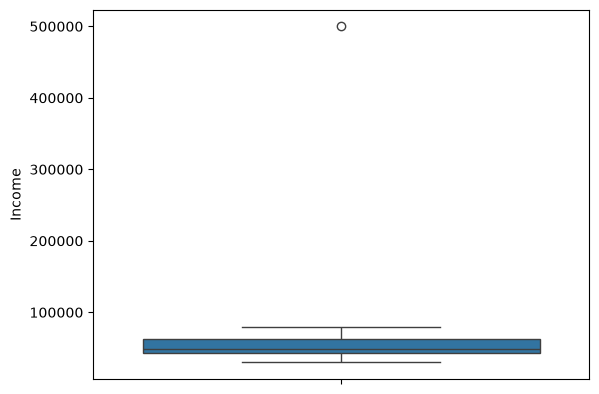

In [56]:
sns.boxplot(data=df["Income"])

<Axes: >

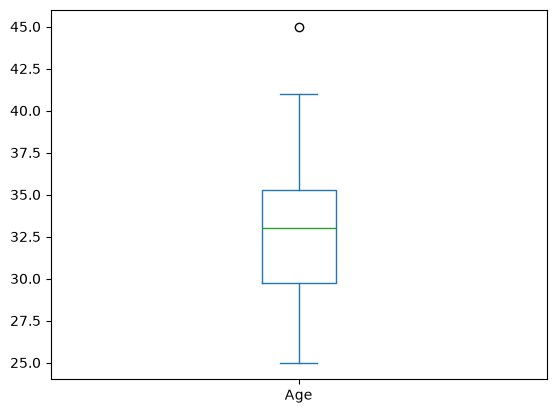

In [57]:
df["Age"].plot.box()